# Тест примеры для поиска лучшего размещения подразделений алгоритмом Kopt

In [1]:
import numpy as np
import networkx as nx
import pandas as pd
import geopandas as gpd
from genesis.core import BestPointsBase, MetricBase, StateBase
from genesis.mclp import BestNodesKoptG
from genesis.best_points import BestNodeHillClimbing
from genesis.states import FirstArrivalUnitState
from genesis.metrics import ArrivalTime, CoverIndex
from genesis.tools import list_dict_concat, kmh_to_mm
from genesis.utils import timing
import matplotlib.pyplot as plt
from genesis.swiss_knife import CMAP_GrGldRd

import osmnx as ox

In [2]:
def load_G():
    return ox.load_graphml("tests/data/test_rng.ml")

def load_G_simplyfied():
    G = load_G()
    return ox.simplify_graph(G)

def load_area():
    return gpd.read_file("tests/data/test_polygon.gpkg")

def create_G():
    '''
        max: 21
        mean: 8.67
        median: 8.0
        ip-10: 66.67
        ip-20: 93.33
    '''
    G = nx.MultiDiGraph()
    G.add_edge(1, 2, key=0, travel_time=3)
    G.add_edge(1, 3, key=0, travel_time=2)
    G.add_edge(1, 4, key=0, travel_time=5)
    G.add_edge(2, 3, key=0, travel_time=2)
    G.add_edge(2, 5, key=0, travel_time=5)
    G.add_edge(2, 6, key=0, travel_time=7)
    G.add_edge(3, 2, key=0, travel_time=3)
    G.add_edge(3, 7, key=0, travel_time=3)
    G.add_edge(3, 8, key=0, travel_time=4)
    G.add_edge(3, 9, key=0, travel_time=5)
    G.add_edge(4, 3, key=0, travel_time=2)
    G.add_edge(4, 8, key=0, travel_time=4)
    G.add_edge(4, 10, key=0, travel_time=12)
    G.add_edge(4, 11, key=0, travel_time=10)
    G.add_edge(5, 8, key=0, travel_time=8)
    G.add_edge(5, 10, key=0, travel_time=8)
    G.add_edge(5, 12, key=0, travel_time=6)
    G.add_edge(5, 13, key=0, travel_time=9)
    G.add_edge(5, 12, key=0, travel_time=8)
    G.add_edge(6, 8, key=0, travel_time=1)
    G.add_edge(6, 9, key=0, travel_time=4)
    G.add_edge(6, 12, key=0, travel_time=4)
    G.add_edge(7, 10, key=0, travel_time=4)
    G.add_edge(7, 11, key=0, travel_time=9)
    G.add_edge(7, 13, key=0, travel_time=7)
    G.add_edge(8, 10, key=0, travel_time=6)
    G.add_edge(8, 13, key=0, travel_time=8)
    G.add_edge(9, 14, key=0, travel_time=10)
    G.add_edge(10, 13, key=0, travel_time=7)
    G.add_edge(10, 14, key=0, travel_time=5)
    G.add_edge(11, 12, key=0, travel_time=7)
    G.add_edge(11, 15, key=0, travel_time=7)
    G.add_edge(12, 13, key=0, travel_time=8)
    return G

In [3]:
# # Загрузка графа и полигона границ
# G = ox.load_graphml("tests/data/test_rng.ml")
# area = gpd.read_file("tests/data/test_polygon.gpkg")

# nodes = list(G.nodes())
# existed_units = {nodes[100]:'A', 
#                 nodes[2000]:'B', 
#                 }
# new_units = {nodes[3000]:'c',
#              nodes[4000]:'d'}

In [3]:
def iter_func(**kwds):
    'Функция вывода хода расчета'
    print(kwds)

## Расчет...

In [5]:
G = create_G()

nodes = list(G.nodes())
new_units = {nodes[3]:'c',
             nodes[8]:'d'}
# new_units = {nodes[100]:'A', 
#             nodes[2000]:'B',
#             nodes[3000]:'c',
#             nodes[4000]:'d'}

BNHC = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       )

BNG = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNHC,
                       iterations=5,
                       ))


optimal_nodes, best_metric = BNG(env=G,
    dynamic_nodes=new_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )

{'best_metric': 9.0, 'dynamic_nodes': {4: 'c', 9: 'd'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 8.307692307692308, 'dynamic_nodes': {3: 'c', 14: 'd'}, 'static_nodes': {}}
{'i': 1, 'best_metric': 8.307692307692308, 'dynamic_nodes': {3: 'c', 14: 'd'}, 'static_nodes': {}}
{'i': 2, 'best_metric': 8.307692307692308, 'dynamic_nodes': {3: 'c', 14: 'd'}, 'static_nodes': {}}
{'i': 3, 'best_metric': 8.307692307692308, 'dynamic_nodes': {3: 'c', 14: 'd'}, 'static_nodes': {}}
{'i': 4, 'best_metric': 8.307692307692308, 'dynamic_nodes': {3: 'c', 14: 'd'}, 'static_nodes': {}}
ВРЕМЯ: 0.04 сек


In [6]:
G = load_G_simplyfied()

nodes = list(G.nodes())
new_units = {
            nodes[500]:'псч-3',
            nodes[1000]:'псч-4',
            }

BNHC = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                    #    all_neighbors=False
                       )

BNG = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNHC,
                       iterations=5,
                       ))


optimal_nodes, best_metric = BNG(env=G,
    dynamic_nodes=new_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )

{'best_metric': 6.565893771428573, 'dynamic_nodes': {2034402245: 'псч-3', 2589929136: 'псч-4'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 5.563807187855296, 'dynamic_nodes': {2034401857: 'псч-3', 426923846: 'псч-4'}, 'static_nodes': {}}
{'i': 1, 'best_metric': 5.563807187855296, 'dynamic_nodes': {2034401857: 'псч-3', 426923846: 'псч-4'}, 'static_nodes': {}}
{'i': 2, 'best_metric': 5.563807187855296, 'dynamic_nodes': {2034401857: 'псч-3', 426923846: 'псч-4'}, 'static_nodes': {}}
{'i': 3, 'best_metric': 5.563807187855296, 'dynamic_nodes': {2034401857: 'псч-3', 426923846: 'псч-4'}, 'static_nodes': {}}
{'i': 4, 'best_metric': 5.563807187855296, 'dynamic_nodes': {2034401857: 'псч-3', 426923846: 'псч-4'}, 'static_nodes': {}}
ВРЕМЯ: 4.5 сек


# Расчет для Красноярского графа

In [4]:
def iter_state_func(**kwds):
    '''
    Печать состояния расчета на итерации
    '''
    # print('Итерация:', kwds['i'])
    print(kwds)
    dynamic_nodes = kwds['dynamic_nodes']
    if isinstance(dynamic_nodes, dict):
        dynamic_nodes_id = list(dynamic_nodes.keys())
    else:
        dynamic_nodes_id = dynamic_nodes

    try:
        static_nodes = kwds['static_nodes']
        if isinstance(static_nodes, dict):
            static_nodes_id = list(static_nodes.keys())
        else:
            static_nodes_id = static_nodes
    except:
        static_nodes = None
        
    if not static_nodes is None:
        if isinstance(dynamic_nodes,list):
            start_nodes = dynamic_nodes+static_nodes
        elif isinstance(dynamic_nodes,dict):
            start_nodes = {**dynamic_nodes, **static_nodes}
    else:
        start_nodes = dynamic_nodes
    times, nearest = FirstArrivalUnitState()(env=G, points=start_nodes)
    times = {k:(1+int(t//5))*5 for k, t in times.items()}

    nx.set_node_attributes(G, pd.Series(nearest, dtype=str), 'nearest')
    nx.set_node_attributes(G, times, 'route_time')

    nds = ox.graph_to_gdfs(G, edges=False)
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
    ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax1)
    nds.plot(ax=ax1, markersize=2, column='nearest', cmap='Set3', legend=True)
    nds.loc[dynamic_nodes_id].plot(ax=ax1, markersize=25, color='red')
    if static_nodes:
        nds.loc[static_nodes_id].plot(ax=ax1, markersize=25, color='k')

    ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax2)
    nds.plot(ax=ax2, markersize=2, column='route_time', cmap=CMAP_GrGldRd, legend=True)
    nds.loc[dynamic_nodes_id].plot(ax=ax2, markersize=25, color='red')
    if static_nodes:
        nds.loc[static_nodes_id].plot(ax=ax2, markersize=25, color='k')

    plt.show()

In [5]:
G = ox.graph_from_place('Красноярск, Россия')
print(G.number_of_nodes())

s1, s2, s3, s4, s5 = [49, 37, 26, 16, 5]
hwy_speeds = {
            "trunk":          s1,           # Важные дороги, не являющиеся автомагистралями
            "trunk_link":     s1,           # Важные дороги, не являющиеся автомагистралями
            "motorway":       s1,           # Автомагистрали 
            "motorway_link":  s1,           # Автомагистрали 
            
            "primary":        s2,           # Автомобильные дороги регионального значения
            "primary_link":   s2,           # Автомобильные дороги регионального значения
            "secondary":      s2,           # Автомобильные дороги областного значения
            "secondary_link": s2,           # Автомобильные дороги областного значения
            "unclassified":   s2,           # Остальные автомобильные дороги местного значения, образующие соединительную сеть дорог.

            "tertiary":       s3,           # Более важные автомобильные дороги среди прочих автомобильных дорог местного значения
            "tertiary_link":  s3,           # Более важные автомобильные дороги среди прочих автомобильных дорог местного значения
            "residential":    s3,           # Дороги, которые проходят внутри жилых зон, а также используются для подъезда к ним
            "living_street":  s3,           # Жилые зоны и дворовые проезды
            
            "road":           s4,           # Линии, возможно, являющиеся дорогами. Временный тег, которым следует помечать линии до уточнения.
            "service":        s4,           # Служебные проезды: внутриквартальные, въездные, парковочные и т.д.
            "track":          s4,           # Дороги сельскохозяйственного назначения, лесные дороги, не ведущие к жилым или промышленным объектам, неофициальные грунтовки, козьи тропы
            
            "footway":        s5,           # Пешеходные дорожки, тротуары. 
            "path":           s5,           # Тропа (чаще всего, стихийная) использующаяся пешеходами, либо одним или несколькими видами транспорта, кроме четырехколесного (лыжи, снегоход, велосипед).
            "pedestrian":     s5,           # Для обозначения улиц городов (такого же класса как residential), выделенных для пешеходов.
            
            "steps":          s5,           # Лестницы, лестничные пролёты. 
            "cycleway":       s5,           # Велодорожка, обозначенная соответствующим дорожным знаком. 
            "bridleway":      s5,           # Дорожки для верховой езды.
            "corridor":       s5,           # Коридоры внутри крупных зданий
}

hwy_speeds = {k: kmh_to_mm(v) for k,v in hwy_speeds.items()}

defSpeed=5
for edge in G.edges:
    road = G.get_edge_data(*edge).get('highway')
    length = G.get_edge_data(*edge).get('length')

    try:
        speed = hwy_speeds.get(road, defSpeed)
    except TypeError: # Тип дороги бывает списком, обычно ['residential', 'сервис']
        if isinstance(road, list):
            speed = hwy_speeds.get(road[0], defSpeed)
        else:
            speed = defSpeed

    G.add_edge(*edge, travel_time=length/speed)

46914


In [8]:
nodes = list(G.nodes())
new_units = {
            nodes[500]:'псч-1',
            nodes[1000]:'псч-2',
            nodes[2000]:'псч-3',
            nodes[3000]:'псч-4',
            nodes[4000]:'псч-5',
            nodes[5000]:'псч-6',
            nodes[6000]:'псч-7',
            nodes[7000]:'псч-8',
            }

In [12]:
BNHC = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                    #    all_neighbors=False
                       )

BNG = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNHC,
                       iterations=5,
                       ))


optimal_nodes, best_metric = BNG(env=G,
    dynamic_nodes=new_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )

{'best_metric': 20.712828777100302, 'dynamic_nodes': {356313823: 'псч-1', 358015031: 'псч-2', 457310528: 'псч-3', 860857666: 'псч-4', 1375952780: 'псч-5', 1706724199: 'псч-6', 1877319734: 'псч-7', 2041362008: 'псч-8'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 18.96180784272922, 'dynamic_nodes': {356318376: 'псч-1', 4444979797: 'псч-2', 433985455: 'псч-3', 316563472: 'псч-4', 418315078: 'псч-5', 5780854032: 'псч-6', 1877319253: 'псч-7', 2641834316: 'псч-8'}, 'static_nodes': {}}
{'i': 1, 'best_metric': 18.223598590798854, 'dynamic_nodes': {346060636: 'псч-1', 4444979797: 'псч-2', 433972135: 'псч-3', 316563472: 'псч-4', 418315078: 'псч-5', 5780854032: 'псч-6', 1877319253: 'псч-7', 2641834316: 'псч-8'}, 'static_nodes': {}}
{'i': 2, 'best_metric': 18.18345245716924, 'dynamic_nodes': {346060623: 'псч-1', 4444979797: 'псч-2', 8833462866: 'псч-3', 316563472: 'псч-4', 418315078: 'псч-5', 5780854032: 'псч-6', 1877319253: 'псч-7', 2641834316: 'псч-8'}, 'static_nodes': {}}
{'i': 3, 'best_metric

{'dynamic_nodes': {346060623: 'псч-1', 4444979797: 'псч-2', 4418944360: 'псч-3', 316563472: 'псч-4', 418315078: 'псч-5', 5780854032: 'псч-6', 1877319253: 'псч-7', 2641834316: 'псч-8'}}


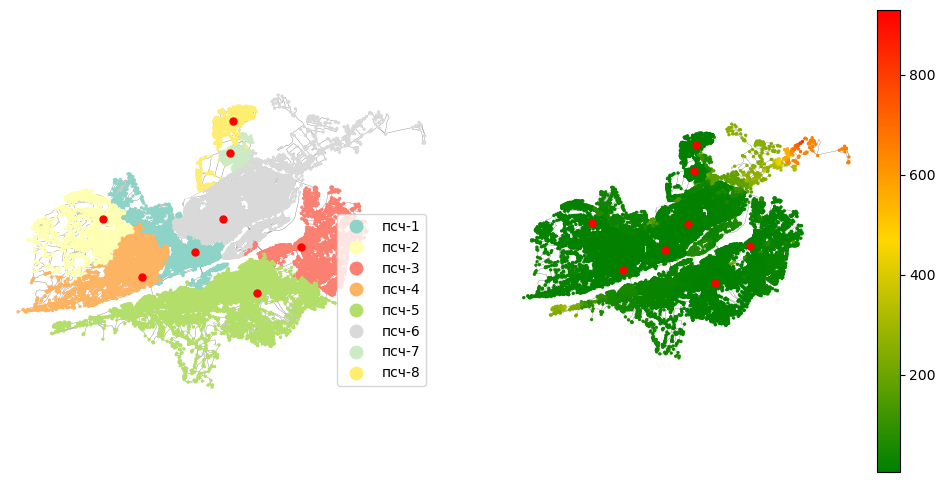

In [13]:
# Печать карт размещения и прибытия
iter_state_func(dynamic_nodes=optimal_nodes)

## Расчет последовательно метриками max+mean time

In [ ]:
# Расчет метрикой max_time
BNHC_max = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(np.max),
                       )
BNG_max = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNHC_max,
                       iterations=5,
                       ))
optimal_nodes, best_metric = BNG_max(env=G,
    dynamic_nodes=new_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )
# Расчет метрикой mean_time
BNHC_mean = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       )
BNG_mean = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNHC_mean,
                       iterations=5,
                       ))
optimal_nodes, best_metric = BNG_mean(env=G,
    dynamic_nodes=optimal_nodes,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )

# Печать карт размещения и прибытия
iter_state_func(dynamic_nodes=optimal_nodes)

Ok